In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
from sklearn.datasets import fetch_kddcup99

data = fetch_kddcup99(subset=None, shuffle=True, random_state=42)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['label'] = data.target

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 494021 rows, 42 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,b'smurf.'
1,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,b'smurf.'
2,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,b'smurf.'
3,0,b'tcp',b'http',b'SF',345,5419,0,0,0,0,...,255,1.0,0.0,0.01,0.02,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'private',b'S0',0,0,0,0,0,0,...,2,0.01,0.07,0.0,0.0,1.0,1.0,0.0,0.0,b'neptune.'


In [4]:
# Simplify labels to binary: normal vs attack
df['label'] = df['label'].apply(lambda x: 0 if x == b'normal.' else 1)

# Encode categorical columns
for col in ['protocol_type', 'service', 'flag']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Check class distribution
print("Normal traffic (0):", (df['label'] == 0).sum())
print("Attack traffic (1):", (df['label'] == 1).sum())
print("\nDataset ready for modeling")

Normal traffic (0): 97278
Attack traffic (1): 396743

Dataset ready for modeling


In [7]:
# Split data into features and target
X = df.drop('label', axis=1)
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 395216
Testing samples: 98805


In [8]:
# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [9]:
# Test the model
y_pred = model.predict(X_test)

# Print results
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19529
      Attack       1.00      1.00      1.00     79276

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



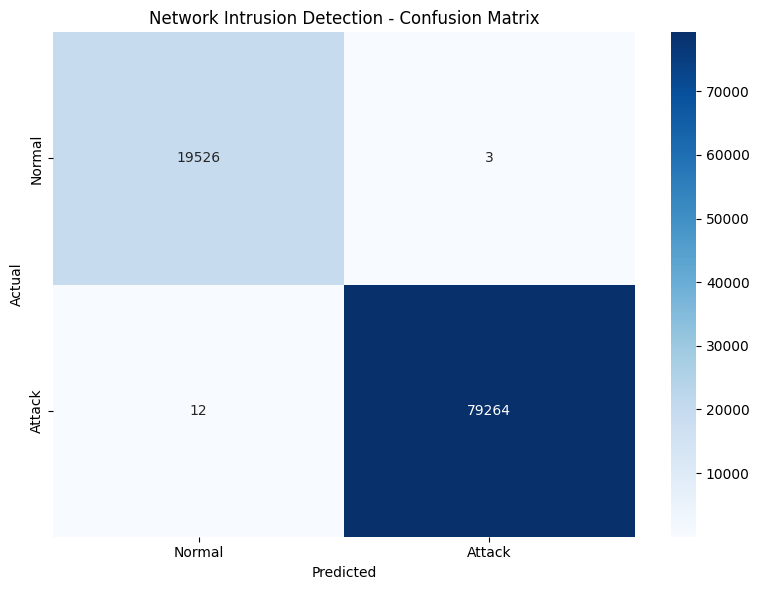

In [10]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Network Intrusion Detection - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

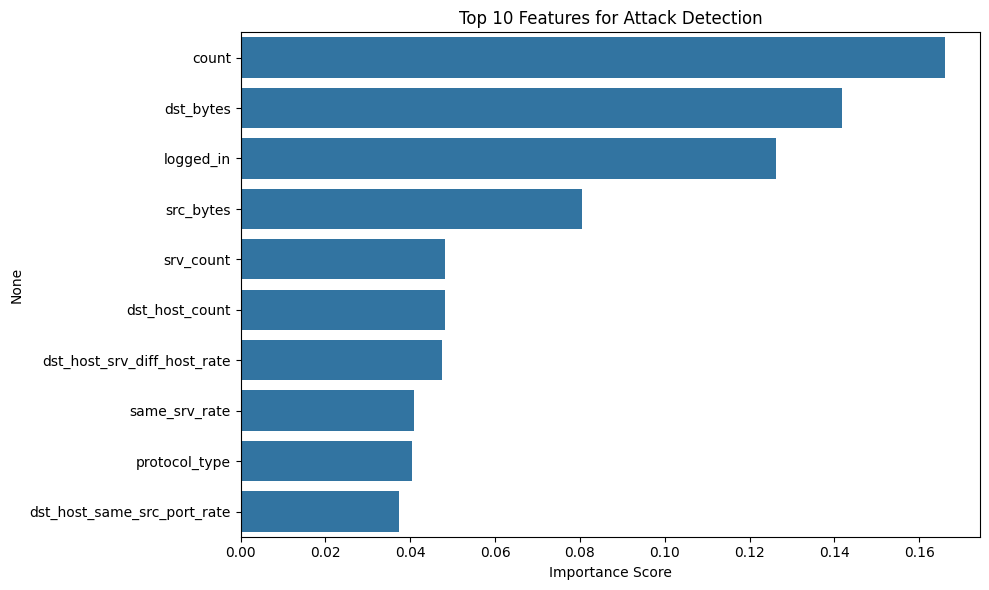

In [11]:
# Feature importance
importances = pd.Series(model.feature_importances_, 
                        index=X.columns).sort_values(ascending=False)[:10]
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 10 Features for Attack Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
# Summary
print("=== Network Intrusion Detection Model Summary ===")
print(f"Dataset: DARPA KDD Cup 1999 (via scikit-learn)")
print(f"Total samples: {len(df)}")
print(f"Model: Random Forest (100 trees)")
print(f"Attacks detected: 79,264 out of 79,276 (99.98%)")
print(f"False alarms: 3 out of 19,529 normal connections")
print(f"Top indicators: connection count, data volume, authentication status")

=== Network Intrusion Detection Model Summary ===
Dataset: DARPA KDD Cup 1999 (via scikit-learn)
Total samples: 494021
Model: Random Forest (100 trees)
Attacks detected: 79,264 out of 79,276 (99.98%)
False alarms: 3 out of 19,529 normal connections
Top indicators: connection count, data volume, authentication status
